In [1]:
import pandas as pd
import torch 
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader

In [2]:
raw_data = pd.read_csv('../data/btcusd_1-min_data.csv',index_col=0)

In [3]:
from preprocess import prepare_intraday_data, calculate_daily_components
intraday_data = prepare_intraday_data(raw_data) 

In [4]:
daily_data = calculate_daily_components(intraday_data)

In [5]:
daily_data

,RV,BPV,ABD_jump,ABD_CSP,BNS_jump,BNS_CSP,Jo_jump,Jo_CSP,RS_plus,RS_minus,Daily_ret,Neg_RV,SJ,SJ_plus,SJ_minus,TQ
2012-01-01,0.003049,0.000000,0.003049,0.000000,0.003049,0.000000,0.003049,0.000000,0.003049,0.000000,0.055216,0.000000,0.003049,0.003049,0.000000,0.000000e+00
2012-01-02,0.001058,0.000000,0.001058,0.000000,0.001058,0.000000,0.001058,0.000000,0.001058,0.000000,0.032523,0.000000,0.001058,0.001058,0.000000,0.000000e+00
2012-01-03,0.007253,0.000000,0.007253,0.000000,0.007253,0.000000,0.007253,0.000000,0.005241,0.002012,0.056380,0.000000,0.003229,0.003229,0.000000,0.000000e+00
2012-01-04,0.009645,0.000000,0.009645,0.000000,0.009645,0.000000,0.009645,0.000000,0.004678,0.004967,0.051577,0.000000,-0.000289,0.000000,-0.000289,0.000000e+00
2012-01-05,0.003875,0.000307,0.003568,0.000307,0.003568,0.000307,0.003568,0.000307,0.003849,0.000027,0.142023,0.000000,0.003822,0.003822,0.000000,0.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-01-22,0.000339,0.000349,0.000000,0.000339,0.000000,0.000339,0.000000,0.000339,0.000158,0.000181,0.001006,0.000000,-0.000023,0.000000,-0.000023,2.275880e-07
2026-01-23,0.000451,0.000447,0.000004,0.000447,0.000004,0.000447,0.000004,0.000447,0.000229,0.000222,0.000324,0.000000,0.000007,0.000007,0.000000,6.061187e-07
2026-01-24,0.000031,0.000026,0.000006,0.000026,0.000006,0.000026,0.000006,0.000026,0.000014,0.000017,-0.004525,0.000031,-0.000003,0.000000,-0.000003,1.139507e-09
2026-01-25,0.000300,0.000310,0.000000,0.000300,0.000000,0.000300,0.000000,0.000300,0.000106,0.000193,-0.028717,0.000300,-0.000087,0.000000,-0.000087,2.365391e-07


In [6]:
from dataloader import create_dataloaders
# 创建DataLoader
train_loader, test_loader = create_dataloaders(daily_data, batch_size=32)

Train shape: (4096, 1, 16, 16)
Test shape:  (1024, 1, 16, 16)


In [7]:
# 检查DataLoader的基本信息
print(f"训练集batch数量: {len(train_loader)}")
print(f"测试集batch数量: {len(test_loader)}")

# 获取一个batch的数据
images, labels = next(iter(train_loader))
print(f"单个batch图像形状: {images.shape}")  # 应该是 [batch_size, 1, 16, 16]
print(f"单个batch标签形状: {labels.shape}")
print(f"标签示例 (前10个): {labels[:10].numpy()}")

# 检查类别分布
all_labels = []
for _, batch_labels in train_loader:
    all_labels.append(batch_labels.numpy())
all_labels = np.concatenate(all_labels)
print(f"训练集类别分布 - 0: {(all_labels == 0).sum()}, 1: {(all_labels == 1).sum()}")

训练集batch数量: 128
测试集batch数量: 32
单个batch图像形状: torch.Size([32, 1, 16, 16])
单个batch标签形状: torch.Size([32])
标签示例 (前10个): [0 1 1 0 1 1 0 0 1 1]
训练集类别分布 - 0: 1850, 1: 2246


In [8]:
# 导入CNN模型和训练函数
from model import CNN_HAR_KS, train_model, evaluate_model

In [9]:
# 设置设备并实例化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 创建模型实例
model = CNN_HAR_KS().to(device)

# 检查模型结构
print("模型结构:")
print(model)

# 计算参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数数量: {total_params:,}")
print(f"可训练参数数量: {trainable_params:,}")

# 使用一个batch测试前向传播
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    print(f"\n测试前向传播:")
    print(f"输入形状: {images.shape}")
    print(f"输出形状: {outputs.shape}")
    print(f"预测类别: {torch.argmax(outputs, dim=1)[:10].cpu().numpy()}")
    print(f"真实标签: {labels[:10].cpu().numpy()}")

使用设备: cuda
模型结构:
CNN_HAR_KS(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=64, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)
总参数数量: 281,154
可训练参数数量: 281,154

测试前向传播:
输入形状: torch.Size([32, 1, 16, 16])
输出形状: torch.Size([32, 2])
预测类别: [0 0 0 0 0 0 0 0 0 0]
真实标签: [1 1 1 1 0 1 1 1 1 0]


In [10]:
# 训练模型
print("开始训练模型...")
num_epochs = 5  # 可以根据需要调整

history = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    num_epochs=num_epochs,
    device=device
)

print("\n训练完成!")
print(f"最终测试准确率: {history['test_acc'][-1]:.4f}")
print(f"最终训练损失: {history['train_loss'][-1]:.4f}")

开始训练模型...
Starting training on cuda...
Epoch [1/5] Loss: 0.6928 | Train Acc: 0.5381 | Test Loss: 0.6920 | Test Acc: 0.5098
Epoch [2/5] Loss: 0.6820 | Train Acc: 0.5454 | Test Loss: 0.6919 | Test Acc: 0.5098
Epoch [3/5] Loss: 0.6725 | Train Acc: 0.5571 | Test Loss: 0.6840 | Test Acc: 0.5352
Epoch [4/5] Loss: 0.6661 | Train Acc: 0.5881 | Test Loss: 0.6800 | Test Acc: 0.5713
Epoch [5/5] Loss: 0.6547 | Train Acc: 0.6038 | Test Loss: 0.6676 | Test Acc: 0.6250

训练完成!
最终测试准确率: 0.6250
最终训练损失: 0.6547


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK SC
findfont: Generic family 'sans-serif' not found because none of the foll

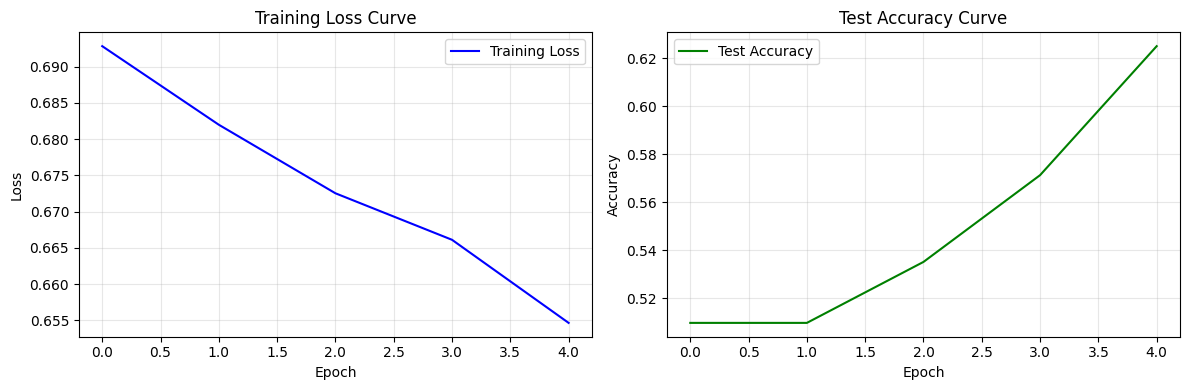

最佳测试准确率: 0.6250 (Epoch 5)
对应训练损失: 0.6547
模型已保存为 cnn_har_ks_model.pth


In [17]:
# 可视化训练结果
import matplotlib.pyplot as plt
#plt.rcParams["font.sans-serif"] = ["Noto Sans CJK SC"]  # 设置中文字体

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 绘制训练损失曲线
axes[0].plot(history['train_loss'], label='Training Loss', color='blue')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Curve')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 绘制测试准确率曲线
axes[1].plot(history['test_acc'], label='Test Accuracy', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Test Accuracy Curve')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# 打印最佳结果
best_epoch = np.argmax(history['test_acc'])
print(f"最佳测试准确率: {history['test_acc'][best_epoch]:.4f} (Epoch {best_epoch+1})")
print(f"对应训练损失: {history['train_loss'][best_epoch]:.4f}")

# 保存模型（可选）
torch.save(model.state_dict(), 'cnn_har_ks_model.pth')
print("模型已保存为 cnn_har_ks_model.pth")